[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_02_modelos_clasificacion.ipynb)

# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality** de UCI, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [ ]:
URL = 'https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv'

df_raw = pd.read_csv(URL)   
print(f'Dataset cargado: {df_raw.shape[0]} registros, {df_raw.shape[1]} columnas')
df_raw.head()

Dataset cargado: 614 registros, 13 columnas


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Verificación de requisitos.....Ejercicio 3 (dataset propio)
n_reg = df_raw.shape[0]
n_feat = df_raw.drop(columns=['Loan_ID', 'Loan_Status']).shape[1]
print(f'Registros: {n_reg}  (mínimo 500) -> {"OK" if n_reg >= 500 else "NO CUMPLE"}')
print(f'Features:  {n_feat}   (mínimo 5)   -> {"OK" if n_feat >= 5 else "NO CUMPLE"}')

print('\nTipos de dato y valores faltantes:')
pd.DataFrame({'dtype': df_raw.dtypes, 'faltantes': df_raw.isna().sum(),
              '% faltante': (df_raw.isna().mean() * 100).round(1)})

Registros: 614  (mínimo 500) -> OK
Features:  11   (mínimo 5)   -> OK

Tipos de dato y valores faltantes:


,dtype,faltantes,% faltante
Loan_ID,str,0,0.0
Gender,str,13,2.1
Married,str,3,0.5
Dependents,str,15,2.4
Education,str,0,0.0
Self_Employed,str,32,5.2
ApplicantIncome,int64,0,0.0
CoapplicantIncome,float64,0,0.0
LoanAmount,float64,22,3.6
Loan_Amount_Term,float64,14,2.3


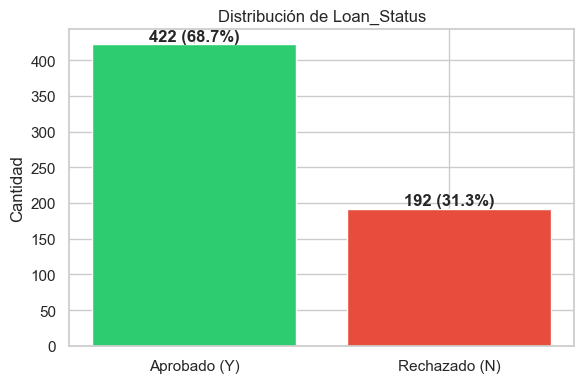

Ratio de desbalance: 2.2:1 (clase mayoritaria vs minoritaria)


In [66]:
# Distribución de la variable objetivo
counts = df_raw['Loan_Status'].value_counts().reindex(['Y', 'N'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Aprobado (Y)', 'Rechazado (N)'], counts.values, color=['#2ecc71', '#e74c3c'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f'{v} ({v/len(df_raw)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribución de Loan_Status')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

print(f'Ratio de desbalance: {counts.max()/counts.min():.1f}:1 (clase mayoritaria vs minoritaria)')

In [59]:
# En mi datasset ya viene con valores binarios y tambien en mi dataset de loan prediction no existe quality

---
## 3. Análisis exploratorio orientado a la clasificacion

In [67]:
# 3.1  Estadísticas descriptivas por clase (variables numéricas)
eda = df_raw.copy()
eda['Dependents'] = eda['Dependents'].replace('3+', '3').astype(float)
eda['Loan_Status'] = eda['Loan_Status'].map({'Y': 1, 'N': 0})
num_eda_all = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
               'Loan_Amount_Term', 'Credit_History', 'Dependents']

comparison = eda.groupby('Loan_Status')[num_eda_all].mean().T
comparison.columns = ['Rechazado (0)', 'Aprobado (1)']
comparison['Diferencia %'] = ((comparison['Aprobado (1)'] - comparison['Rechazado (0)'])
                              / comparison['Rechazado (0)'] * 100).round(1)
comparison.round(2)

,Rechazado (0),Aprobado (1),Diferencia %
ApplicantIncome,5446.08,5384.07,-1.1
CoapplicantIncome,1877.81,1504.52,-19.9
LoanAmount,151.22,144.29,-4.6
Loan_Amount_Term,344.06,341.07,-0.9
Credit_History,0.54,0.98,81.2
Dependents,0.75,0.77,2.0


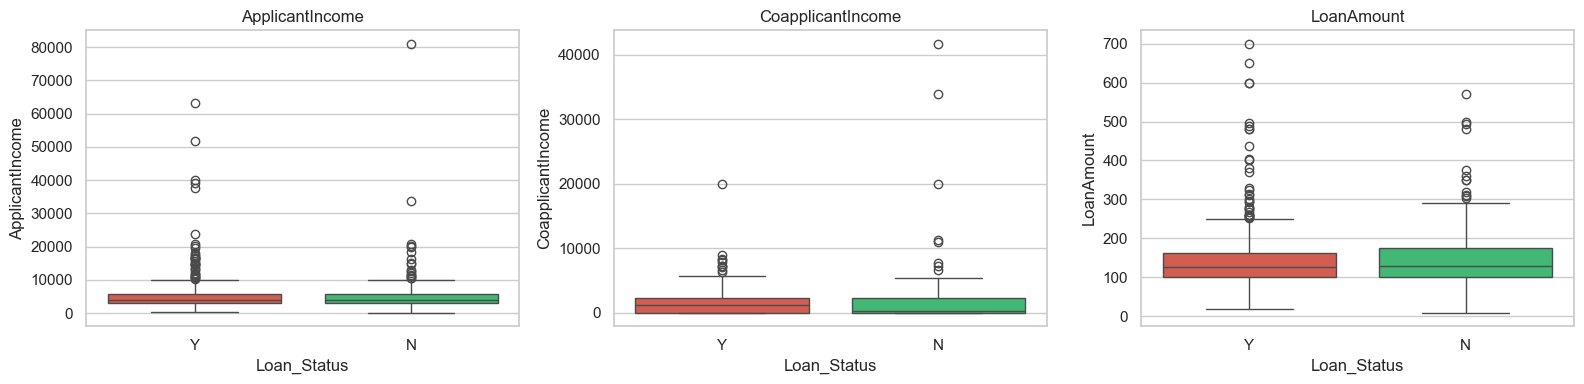

In [68]:
# 3.2  Distribución de variables numéricas por clase (hay asimetría y outliers fuertes)
num_box = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_box):
    sns.boxplot(data=df_raw, x='Loan_Status', y=col, ax=ax, hue='Loan_Status',
                palette=['#e74c3c', '#2ecc71'], legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

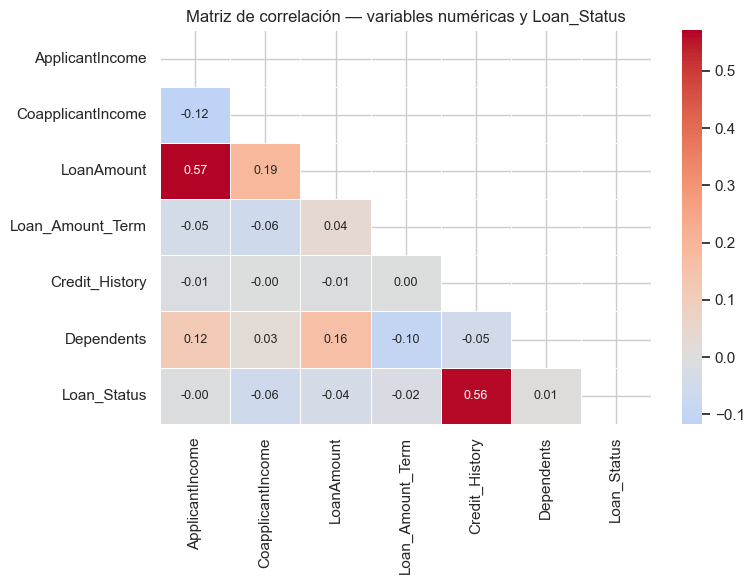

In [69]:
# 3.3  Correlación entre features (numéricas + objetivo codificado 0/1)
corr = eda[num_eda_all + ['Loan_Status']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Matriz de correlación — variables numéricas y Loan_Status')
plt.tight_layout()
plt.show()

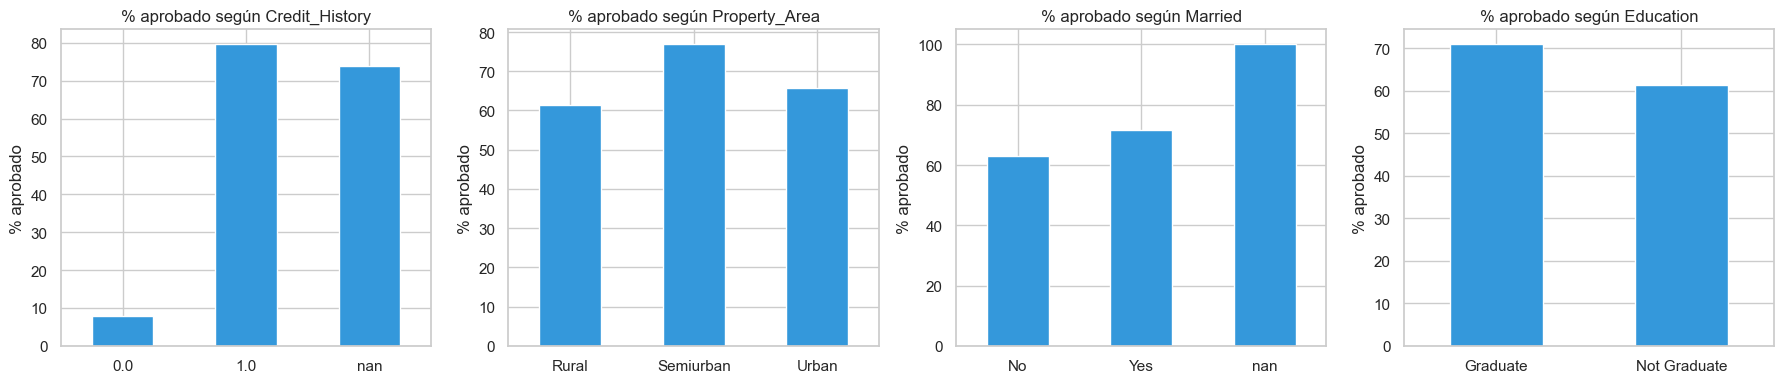

In [70]:
# 3.4  Tasa de aprobación según variables categóricas
cat_eda = ['Credit_History', 'Property_Area', 'Married', 'Education']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_eda):
    tasa = eda.groupby(col, dropna=False)['Loan_Status'].mean() * 100
    tasa.plot(kind='bar', ax=ax, color='#3498db', rot=0)
    ax.set_title(f'% aprobado según {col}')
    ax.set_ylabel('% aprobado')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [72]:
# 4.1  Limpieza y separación features / target
# Se parte siempre de df_raw, así esta celda se puede re-ejecutar sin errores
df = df_raw.drop(columns=['Loan_ID']).copy()
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(float)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
            'Loan_Amount_Term', 'Credit_History', 'Dependents']
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

X = df.drop(columns='Loan_Status')
y = df['Loan_Status']
print(f'Features numéricas ({len(num_cols)}): {num_cols}')
print(f'Features categóricas ({len(cat_cols)}): {cat_cols}')

Features numéricas (6): ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Dependents']
Features categóricas (5): ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']


In [73]:
# 4.2  Split estratificado 80/20 y validación cruzada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 (aprobado) en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 (aprobado) en test:  {y_test.mean():.3f}')

Train: 491 muestras  |  Test: 123 muestras
Proporción clase 1 (aprobado) en train: 0.686
Proporción clase 1 (aprobado) en test:  0.691


In [74]:
# 4.3  Verificación de escalas y faltantes 
print('Rangos de las features numéricas (train):')
print('=' * 60)
for col in num_cols:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:20s}  [{mn:10.2f}, {mx:10.2f}]  rango: {mx-mn:.2f}')

faltantes = X_train.isna().sum()
print('\nValores faltantes en train (se imputan dentro del Pipeline):')
print(faltantes[faltantes > 0].to_string())

print('\n→ Las escalas difieren enormemente (ingresos en miles vs. Credit_History en 0/1).')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features numéricas (train):
ApplicantIncome       [    210.00,   81000.00]  rango: 80790.00
CoapplicantIncome     [      0.00,   41667.00]  rango: 41667.00
LoanAmount            [      9.00,     700.00]  rango: 691.00
Loan_Amount_Term      [     12.00,     480.00]  rango: 468.00
Credit_History        [      0.00,       1.00]  rango: 1.00
Dependents            [      0.00,       3.00]  rango: 3.00

Valores faltantes en train (se imputan dentro del Pipeline):
Gender              11
Married              3
Dependents           8
Self_Employed       27
LoanAmount          20
Loan_Amount_Term    12
Credit_History      43

→ Las escalas difieren enormemente (ingresos en miles vs. Credit_History en 0/1).
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


In [76]:
# 4.4  Preprocesador reutilizable (imputación + escalado + One-Hot)
def make_preprocessor(num_cols, cat_cols, scale=True):
    num_steps = [('imp', SimpleImputer(strategy='median'))]
    if scale:
        num_steps.append(('sc', StandardScaler()))
    cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                         ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    return ColumnTransformer([('num', Pipeline(num_steps), num_cols),
                              ('cat', cat_pipe, cat_cols)])


def build_pipe(clf, num_cols=num_cols, cat_cols=cat_cols, scale=True):
    return Pipeline([('prep', make_preprocessor(num_cols, cat_cols, scale)), ('clf', clf)])


def feature_names(pipe):
    # nombres reales de las columnas tras el preprocesamiento (pipe ya entrenado)
    return [n.split('__', 1)[1] for n in pipe.named_steps['prep'].get_feature_names_out()]

print('Preprocesador definido.')

Preprocesador definido.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [77]:
# 5.1  Pipeline con preprocesamiento + validación cruzada
pipe_lr = build_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                        class_weight='balanced'))  # compensar desbalance

scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.8110 ± 0.0569


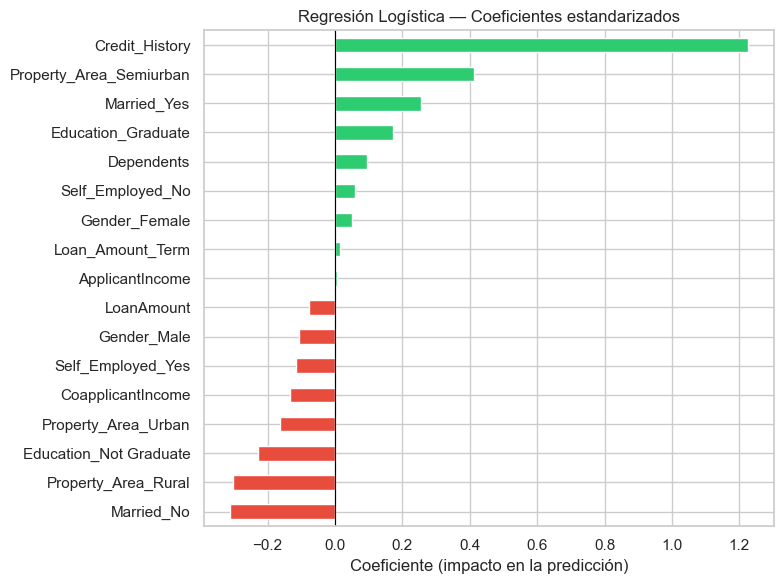


Interpretación: un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Aprobado".
Las variables One-Hot (p. ej. Property_Area_Urban) indican el efecto de pertenecer a esa categoría.


In [78]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(pipe_lr.named_steps['clf'].coef_[0], index=feature_names(pipe_lr)).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Aprobado".')
print('Las variables One-Hot (p. ej. Property_Area_Urban) indican el efecto de pertenecer a esa categoría.')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [79]:
# 6.1  Pipeline (el árbol no necesita estandarización; se usa el mismo preprocesador por simplicidad)
pipe_dt = build_pipe(DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=10,
    class_weight='balanced', random_state=RANDOM_STATE
))

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.7550 ± 0.0240


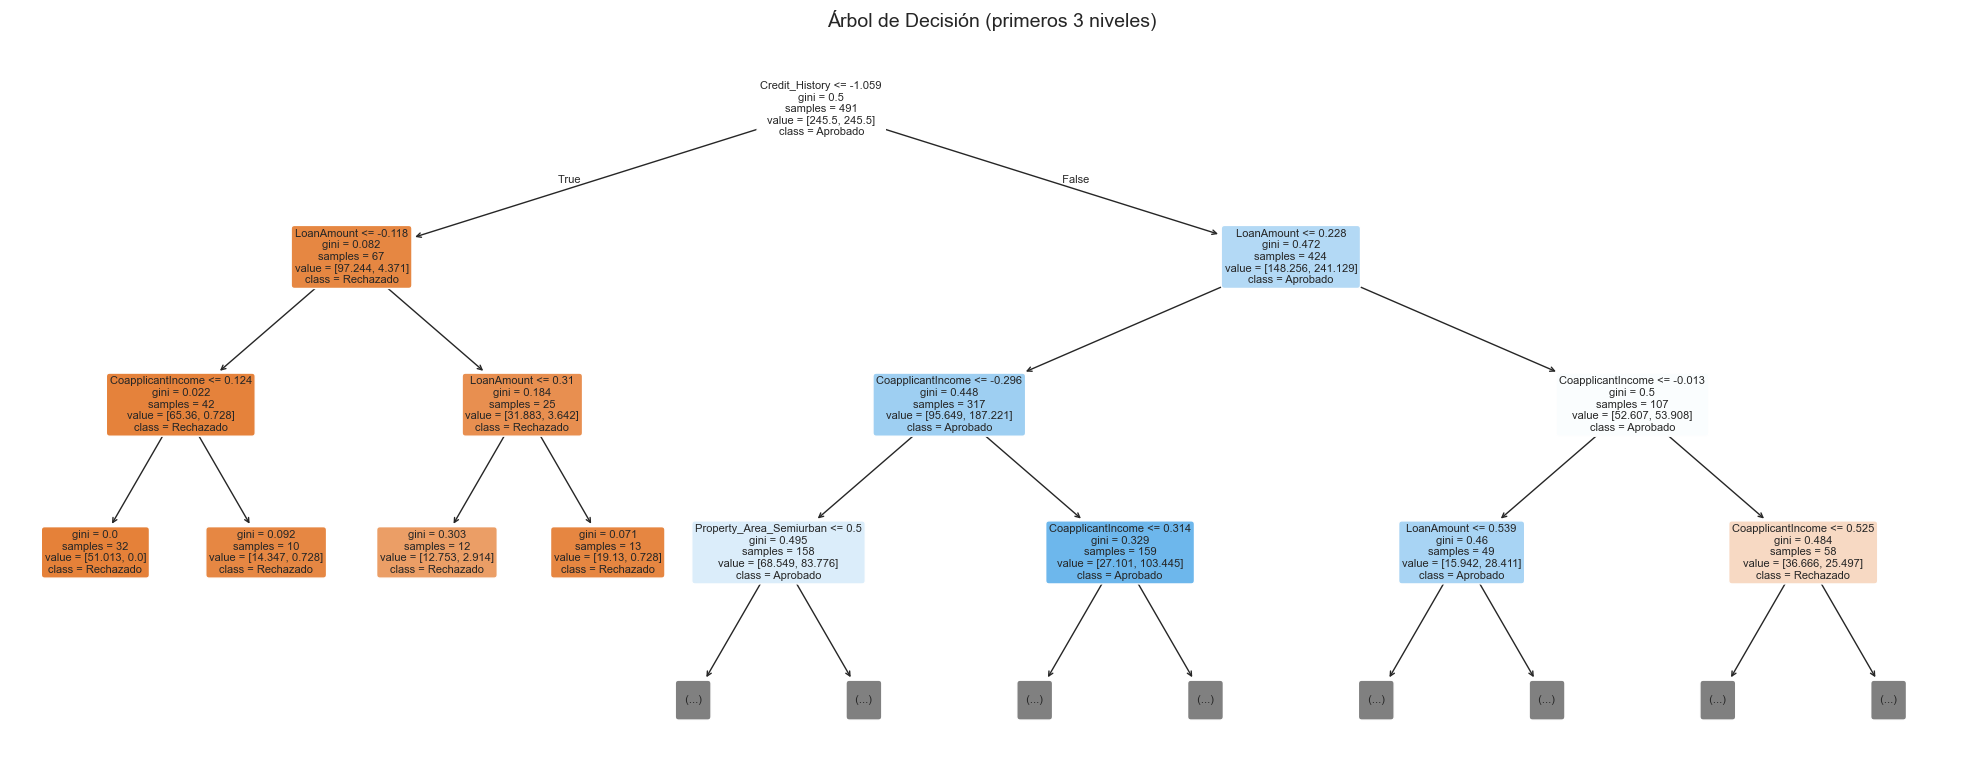

In [80]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=feature_names(pipe_dt),
    class_names=['Rechazado', 'Aprobado'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

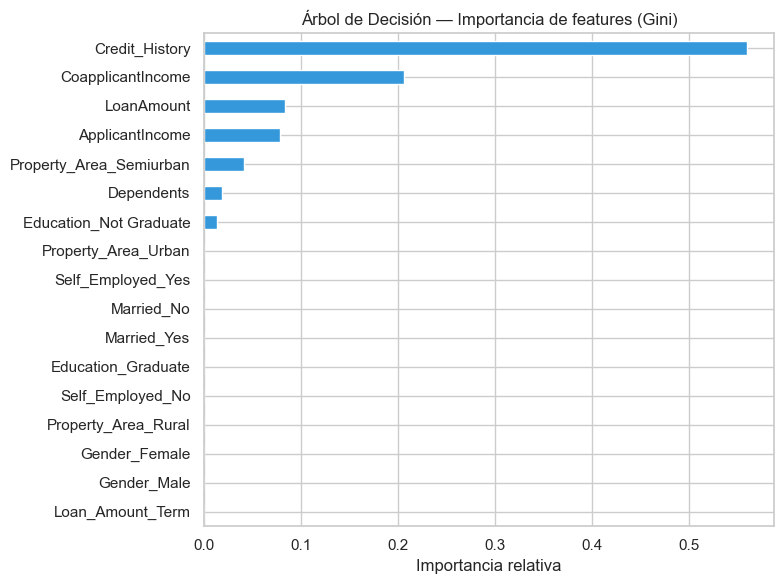

In [81]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(pipe_dt.named_steps['clf'].feature_importances_,
                        index=feature_names(pipe_dt)).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

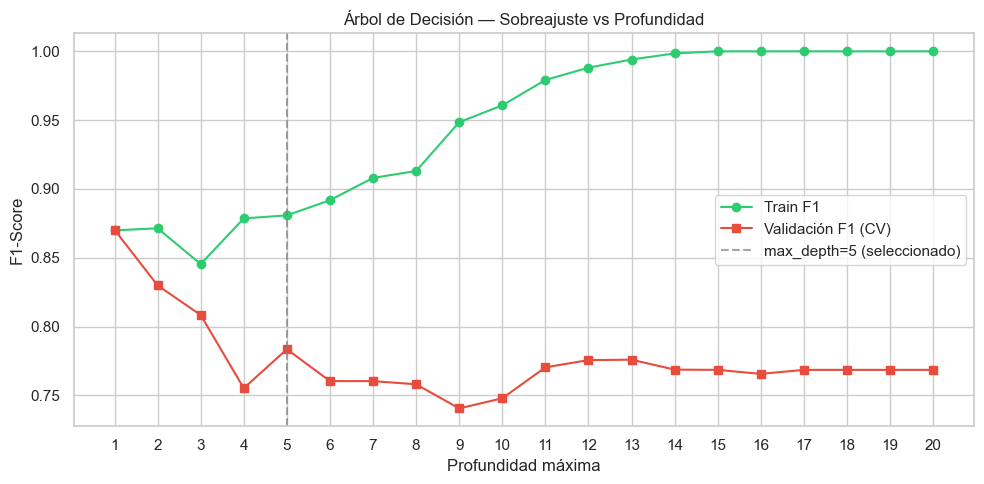

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [82]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores, val_scores = [], []

for d in depths:
    dt = build_pipe(DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                           random_state=RANDOM_STATE))
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    val_scores.append(cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1').mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [83]:
# 7.1  Comparación de kernels (hiperparámetros por defecto)
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_k = build_pipe(SVC(kernel=kernel, class_weight='balanced',
                            random_state=RANDOM_STATE, probability=True))
    scores = cross_val_score(pipe_k, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.8703 ± 0.0271
SVM (rbf   ) — F1 CV: 0.8344 ± 0.0321
SVM (poly  ) — F1 CV: 0.8624 ± 0.0280

Mejor kernel: linear


In [84]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = build_pipe(SVC(kernel=best_kernel, class_weight='balanced',
                          random_state=RANDOM_STATE, probability=True))
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [85]:
# 7.3  Impacto de la estandarización en SVM
# (en ambos casos se imputa y se aplica One-Hot; solo cambia el StandardScaler)
# max_iter acota el entrenamiento: sin escalar, el SVM converge muy lento (o no converge)
svm_no_scale = build_pipe(SVC(kernel=best_kernel, class_weight='balanced',
                              random_state=RANDOM_STATE, max_iter=100_000), scale=False)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es crítica para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.8703
  SIN StandardScaler: F1 = 0.4809
  Diferencia: +38.93 puntos porcentuales

→ La estandarización es crítica para modelos basados en distancias.


## Ejercicio 1:

In [86]:
# Ejercicio 1 — búsqueda de hiperparámetros
param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly'],
}

grid = GridSearchCV(
    build_pipe(SVC(class_weight='balanced', random_state=RANDOM_STATE)),
    param_grid, cv=cv, scoring='f1', n_jobs=-1, refit=True
)
grid.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid.best_params_)
print(f'Mejor F1 (CV, train):  {grid.best_score_:.4f}')

y_pred_grid = grid.predict(X_test)

Mejores hiperparámetros: {'clf__C': 1, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
Mejor F1 (CV, train):  0.8687


In [88]:
# comparación contra el SVM base
comp1 = pd.DataFrame({
    'Modelo': [f'SVM base ({best_kernel})', 'SVM GridSearchCV'],
    'F1 CV': [scores_svm.mean(), grid.best_score_],
    'F1 Test': [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_grid)],
    'Accuracy Test': [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_grid)],
}).round(4)
display(comp1)

dif_cv = (grid.best_score_ - scores_svm.mean()) * 100
dif_te = (f1_score(y_test, y_pred_grid) - f1_score(y_test, y_pred_svm)) * 100
print(f'Mejora en F1 CV:   {dif_cv:+.2f} puntos porcentuales')
print(f'Mejora en F1 Test: {dif_te:+.2f} puntos porcentuales')
print('\nNota: el F1 de CV del grid es optimista (se eligió el máximo entre 32 combinaciones')
print('sobre los mismos folds). El F1 en test es la comparación más honesta.')

,Modelo,F1 CV,F1 Test,Accuracy Test
0,SVM base (linear),0.8703,0.9032,0.8537
1,SVM GridSearchCV,0.8687,0.9081,0.8618


Mejora en F1 CV:   -0.15 puntos porcentuales
Mejora en F1 Test: +0.49 puntos porcentuales

Nota: el F1 de CV del grid es optimista (se eligió el máximo entre 32 combinaciones
sobre los mismos folds). El F1 en test es la comparación más honesta.


,kernel,C,gamma,mean_test_score,std_test_score,rank_test_score
0,rbf,1.0,0.01,0.8687,0.0259,1
1,poly,0.1,auto,0.8666,0.0248,2
2,poly,1.0,0.1,0.8629,0.0266,3
3,poly,1.0,scale,0.8624,0.0280,4
4,rbf,0.1,0.01,0.8619,0.0274,5


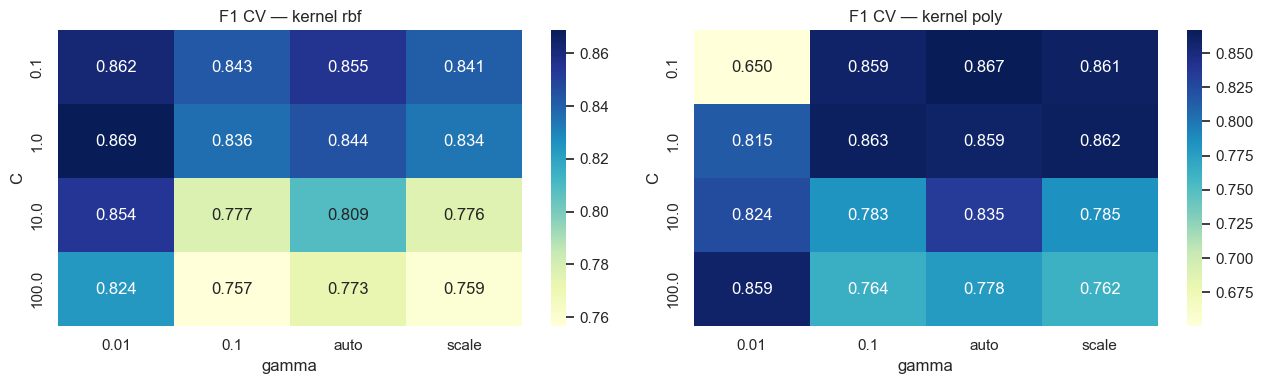

In [89]:
# top 5 combinaciones y mapa de calor F1 (C vs gamma) por kernel
res = pd.DataFrame(grid.cv_results_)
res['C'] = res['param_clf__C']
res['gamma'] = res['param_clf__gamma'].astype(str)
res['kernel'] = res['param_clf__kernel']

display(res.sort_values('rank_test_score')[['kernel', 'C', 'gamma', 'mean_test_score', 'std_test_score', 'rank_test_score']]
        .head(5).round(4).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, kern in zip(axes, ['rbf', 'poly']):
    piv = res[res['kernel'] == kern].pivot(index='C', columns='gamma', values='mean_test_score')
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
    ax.set_title(f'F1 CV — kernel {kern}')
plt.tight_layout()
plt.show()

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

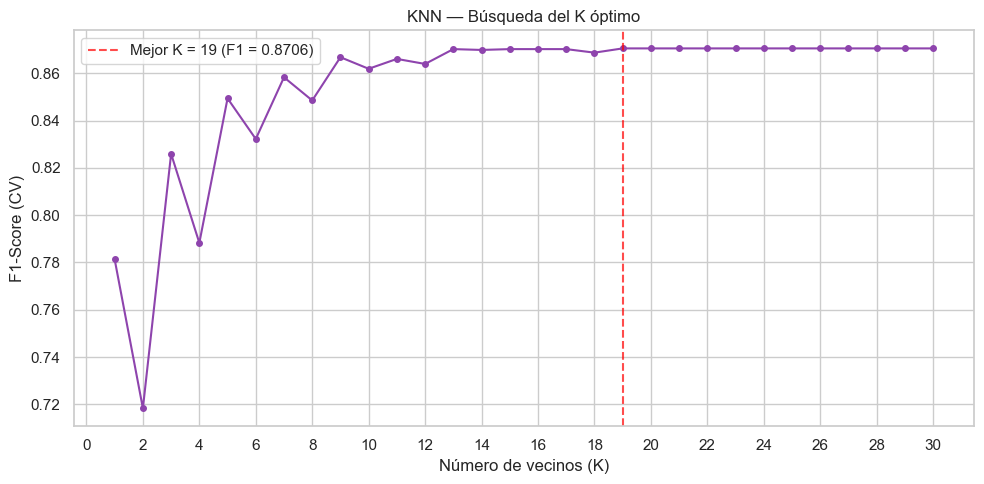

K óptimo: 19


In [90]:
# 8.1  Búsqueda del K óptimo
def find_best_k(X_tr, y_tr, scoring, cv, num_c, cat_c, k_max=30):
    ks = list(range(1, k_max + 1))
    sc = [cross_val_score(build_pipe(KNeighborsClassifier(n_neighbors=k), num_c, cat_c),
                          X_tr, y_tr, cv=cv, scoring=scoring).mean() for k in ks]
    return ks[int(np.argmax(sc))], sc

best_k, k_scores = find_best_k(X_train, y_train, 'f1', cv, num_cols, cat_cols)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 31), k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [91]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = build_pipe(KNeighborsClassifier(n_neighbors=best_k))

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=19) — F1 CV: 0.8706 ± 0.0270


---
## 9. Análisis comparativo de modelos

In [92]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression':  (pipe_lr,  y_pred_lr,  scores_lr),
    'Decision Tree':        (pipe_dt,  y_pred_dt,  scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':    (pipe_knn, y_pred_knn, scores_knn),
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('=' * 80)
print('COMPARACIÓN DE MODELOS — Loan Prediction')
print('=' * 80)
summary_df

COMPARACIÓN DE MODELOS — Loan Prediction


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.8110,0.0569,0.8211,0.8721
1,Decision Tree,0.7550,0.0240,0.7480,0.8025
2,SVM (linear),0.8703,0.0271,0.8537,0.9032
3,KNN (K=19),0.8706,0.0270,0.8537,0.9032


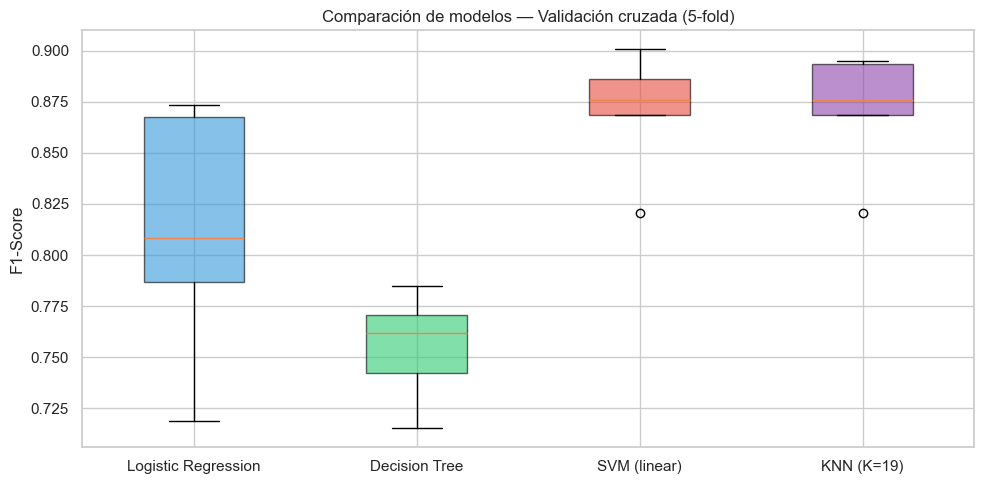

In [94]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [m[2] for m in models.values()]
bp = ax.boxplot(cv_data, tick_labels=list(models.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

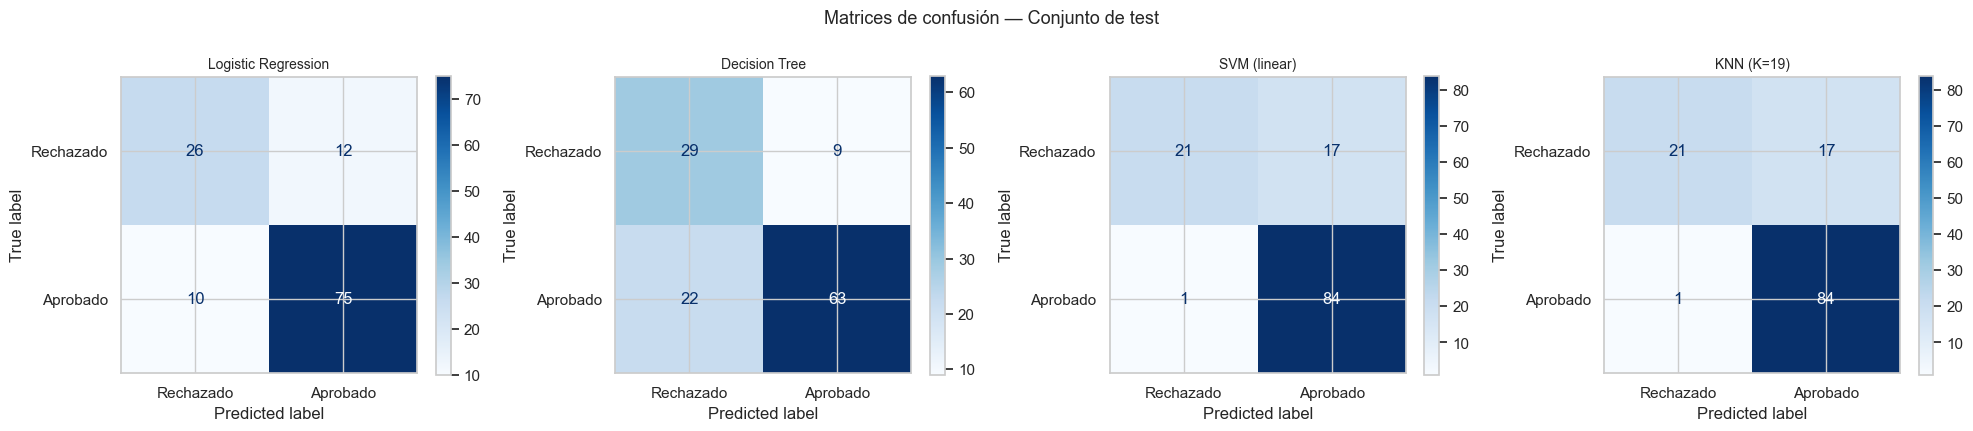

In [95]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Rechazado', 'Aprobado'], cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)
fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

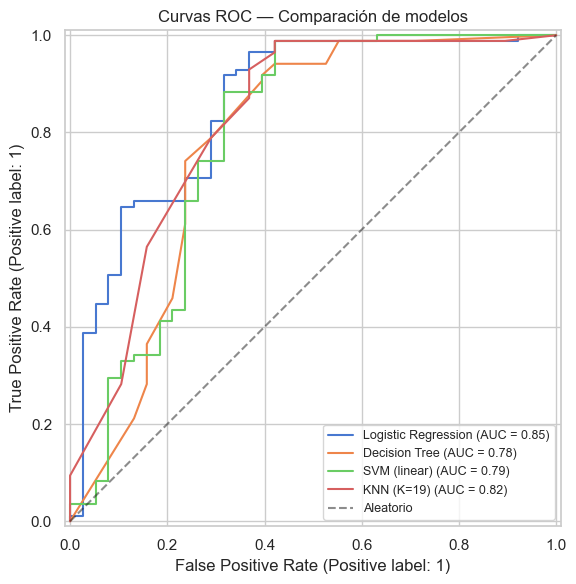

In [96]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))
for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [97]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: models[k][2].mean())
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('=' * 60)
print(classification_report(y_test, best_pred, target_names=['Rechazado', 'Aprobado']))


Mejor modelo: KNN (K=19)
              precision    recall  f1-score   support

   Rechazado       0.95      0.55      0.70        38
    Aprobado       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [98]:
# 9.6  ¿Coinciden las variables más influyentes en LR y Árbol?
top_lr = list(coefs.abs().sort_values(ascending=False).index[:3])
top_dt = list(importances.sort_values(ascending=False).index[:3])
print('Top 3 por |coeficiente| (Regresión Logística):', top_lr)
print('Top 3 por importancia (Árbol de Decisión):    ', top_dt)

Top 3 por |coeficiente| (Regresión Logística): ['Credit_History', 'Property_Area_Semiurban', 'Married_No']
Top 3 por importancia (Árbol de Decisión):     ['Credit_History', 'CoapplicantIncome', 'LoanAmount']


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

### Hallazgos del Ejercicio 3 (despues de ejecutar)
1. **Mejor modelo** y diferencia frente a los demás.
2. **Desbalance de clases**: efecto en las matrices de confusión; ¿qué modelo detecta mejor a los rechazados?
3. **Variables más influyentes** según LR y árbol (secciones 5.2, 6.3 y 9.6) y si coinciden.
4. **Sensibilidad al preprocesamiento**: efecto del escalado en SVM (7.3) e imputación de faltantes.
5. **Efecto del ajuste de hiperparámetros** (Ejercicio 1, sección 7.4): ¿compensa frente al SVM base?
6. **Limitaciones**: pocas muestras (614), valores imputados, outliers en ingresos.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

## resuelto en la **sección 7.4**.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

# resuelto al final

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

se resuelve a continuación, aparte, junto al ejercicio 2,porque cambia el objetivo y obliga a reentrenar los 4 modelos.

## Ejercicio 2:

In [99]:
# Datos para el problema multiclase (objetivo = Property_Area)
y2 = df['Property_Area']
X2 = df.drop(columns='Property_Area')

num_cols2 = num_cols + ['Loan_Status']                    # Loan_Status (0/1) ahora es feature
cat_cols2 = [c for c in cat_cols if c != 'Property_Area']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=RANDOM_STATE, stratify=y2)

print('Distribución de clases (train):')
print(y2_train.value_counts().to_string())
print('\nProporciones:', (y2_train.value_counts(normalize=True).round(3)).to_dict())

Distribución de clases (train):
Property_Area
Semiurban    186
Urban        162
Rural        143

Proporciones: {'Semiurban': 0.379, 'Urban': 0.33, 'Rural': 0.291}


In [100]:
# 11.2  Los 4 modelos en multiclase (K por f1_macro) + baseline
best_k2, _ = find_best_k(X2_train, y2_train, 'f1_macro', cv, num_cols2, cat_cols2)
print('K óptimo (f1_macro):', best_k2)

models2 = {
    'Logistic Regression': build_pipe(LogisticRegression(max_iter=1000, class_weight='balanced',
                                                         random_state=RANDOM_STATE), num_cols2, cat_cols2),
    'Decision Tree':       build_pipe(DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                                             class_weight='balanced',
                                                             random_state=RANDOM_STATE), num_cols2, cat_cols2),
    'SVM (rbf)':           build_pipe(SVC(kernel='rbf', class_weight='balanced',
                                          random_state=RANDOM_STATE), num_cols2, cat_cols2),
    f'KNN (K={best_k2})':  build_pipe(KNeighborsClassifier(n_neighbors=best_k2), num_cols2, cat_cols2),
    'Baseline (clase mayoritaria)': build_pipe(DummyClassifier(strategy='most_frequent'), num_cols2, cat_cols2),
}

rows, preds2 = [], {}
for name, pipe in models2.items():
    cv_macro = cross_val_score(pipe, X2_train, y2_train, cv=cv, scoring='f1_macro')
    pipe.fit(X2_train, y2_train)
    yp = pipe.predict(X2_test)
    preds2[name] = yp
    rows.append({
        'Modelo': name,
        'F1 macro CV': cv_macro.mean(),
        'F1 macro': f1_score(y2_test, yp, average='macro'),
        'F1 micro': f1_score(y2_test, yp, average='micro'),
        'F1 weighted': f1_score(y2_test, yp, average='weighted'),
        'Accuracy': accuracy_score(y2_test, yp),
    })

res2 = pd.DataFrame(rows).round(4)
res2

K óptimo (f1_macro): 8


,Modelo,F1 macro CV,F1 macro,F1 micro,F1 weighted,Accuracy
0,Logistic Regression,0.3630,0.3984,0.4228,0.4062,0.4228
1,Decision Tree,0.3839,0.4186,0.4309,0.4083,0.4309
2,SVM (rbf),0.3732,0.3311,0.3659,0.3407,0.3659
3,KNN (K=8),0.3836,0.3647,0.3740,0.3722,0.3740
4,Baseline (clase mayoritaria),0.1832,0.1843,0.3821,0.2113,0.3821


#### Elección de la métrica F1 (macro vs micro vs weighted)
- **micro**: cuenta todos los aciertos/errores juntos; en clasificación de una sola etiqueta por muestra es **idéntico al accuracy** (compruébalo en la tabla), así que no aporta información nueva y favorece a las clases grandes.
- **weighted**: promedia el F1 por clase ponderando por su tamaño; refleja el rendimiento "típico" por muestra, pero un mal desempeño en una clase pequeña queda diluido.
- **macro**: promedia el F1 de cada clase con el **mismo peso**; penaliza a un modelo que ignora una clase.

Para este problema, `macro` es la más adecuada si se quiere que ninguna zona sea ignorada; `weighted` es aceptable porque las clases están razonablemente equilibradas (ver distribución en 11.1), y por eso ambas deberían dar valores parecidos. Verifica con la tabla anterior.

F1 por clase (test) — ¿qué clases son más difíciles de distinguir?


,Logistic Regression,Decision Tree,SVM (rbf),KNN (K=8),Baseline (clase mayoritaria)
Rural,0.375,0.510,0.295,0.299,0.000
Semiurban,0.522,0.290,0.479,0.458,0.553
Urban,0.299,0.456,0.219,0.337,0.000


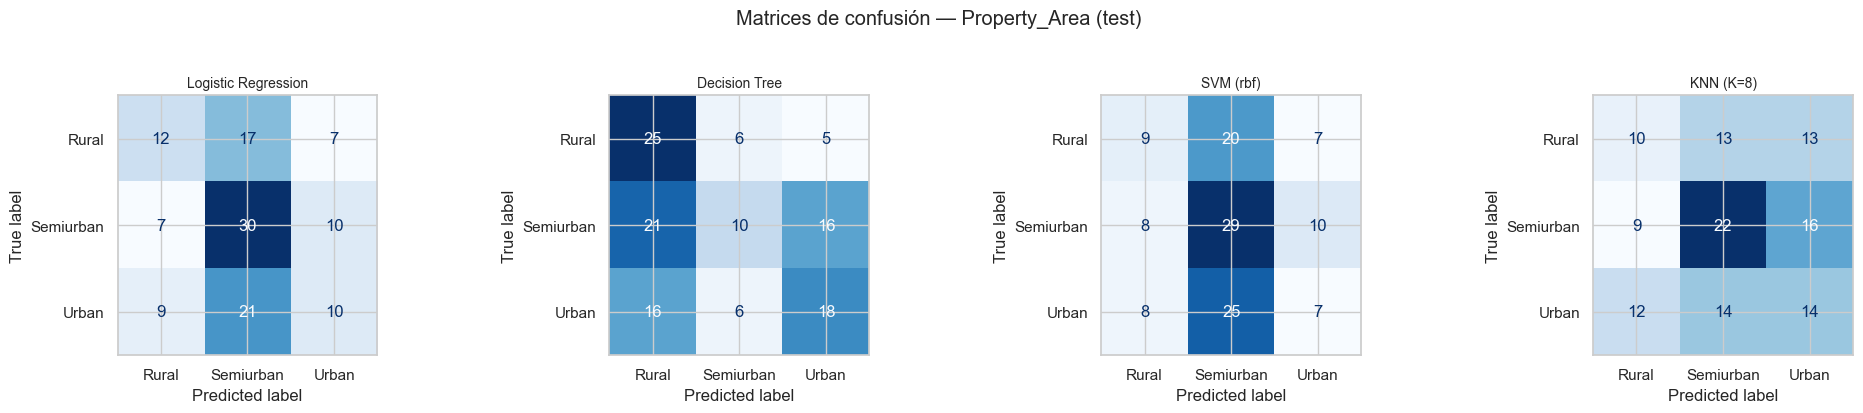

In [101]:
# 11.3  F1 por clase y matrices de confusión
clases = sorted(y2.unique())
por_clase = pd.DataFrame(
    {name: f1_score(y2_test, yp, average=None, labels=clases) for name, yp in preds2.items()},
    index=clases).round(3)
print('F1 por clase (test) — ¿qué clases son más difíciles de distinguir?')
display(por_clase)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, yp) in zip(axes, list(preds2.items())[:4]):
    ConfusionMatrixDisplay.from_predictions(y2_test, yp, labels=clases, cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
fig.suptitle('Matrices de confusión — Property_Area (test)', y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# 11.4  Comparación contra el baseline
base_row = res2[res2['Modelo'].str.startswith('Baseline')].iloc[0]
print(f"Baseline (clase mayoritaria): accuracy = {base_row['Accuracy']:.3f} | F1 macro = {base_row['F1 macro']:.3f}\n")
for _, r in res2[~res2['Modelo'].str.startswith('Baseline')].iterrows():
    print(f"{r['Modelo']:22s} accuracy {r['Accuracy'] - base_row['Accuracy']:+.3f} | F1 macro {r['F1 macro'] - base_row['F1 macro']:+.3f} vs baseline")
print('\nSi la ganancia es pequeña, las variables disponibles casi no informan sobre Property_Area;')
print('ese es un hallazgo válido para el análisis.')

Baseline (clase mayoritaria): accuracy = 0.382 | F1 macro = 0.184

Logistic Regression    accuracy +0.041 | F1 macro +0.214 vs baseline
Decision Tree          accuracy +0.049 | F1 macro +0.234 vs baseline
SVM (rbf)              accuracy -0.016 | F1 macro +0.147 vs baseline
KNN (K=8)              accuracy -0.008 | F1 macro +0.180 vs baseline

Si la ganancia es pequeña, las variables disponibles casi no informan sobre Property_Area;
ese es un hallazgo válido para el análisis.


---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*